In [1]:
import matplotlib.pyplot as plt
from PIL import Image

def show_results(results):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        img = Image.open(r["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{r['score']:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [3]:
from pathlib import Path
from R2 import FashionEmbedder, FashionSearchEngine

embedder = FashionEmbedder()
search_engine = FashionSearchEngine(embedder=embedder)

dataset_dir = Path("dataset/images")
image_paths = sorted([p for p in dataset_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])

search_engine.build_index(image_paths)
search_engine.save("vdb/R2.bin")

Using device: mps


Building Search Index: 100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


Indexed 3200 images successfully.


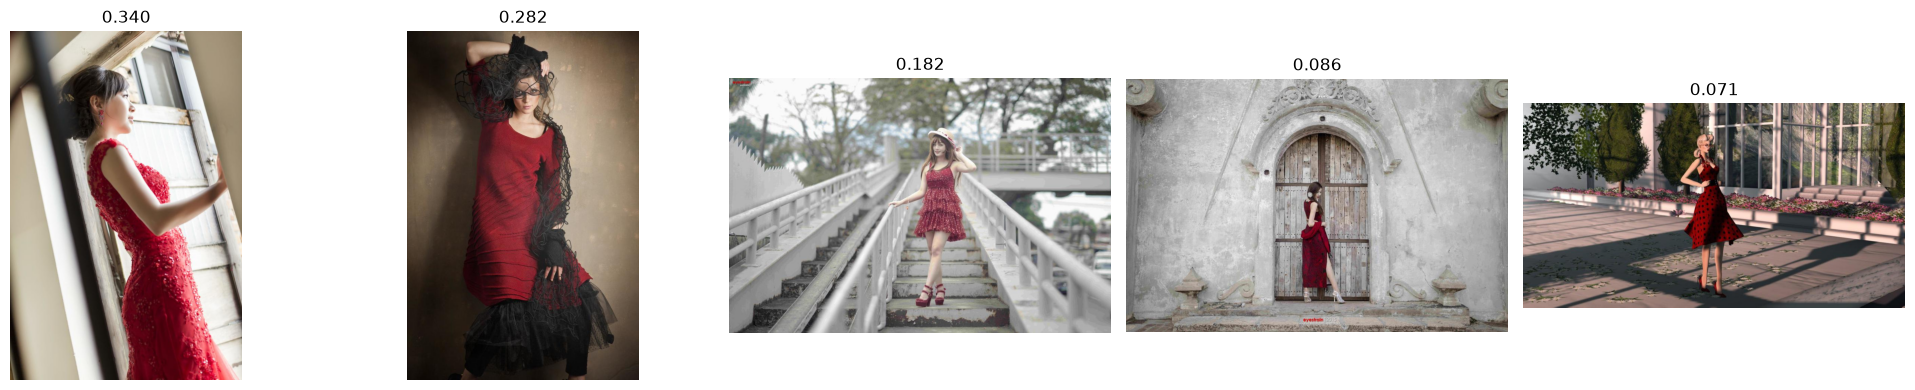

In [4]:
results = search_engine.query("vintage red dress", k_initial=30, k_final=5)
show_results(results)